<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/Copy_of_Online_Retail.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**1.Chuẩn bị vấn đề**

##**1.1.Khai báo thư viện**

In [81]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import apriori, association_rules

##**1.2.Nạp dữ liệu**

In [82]:
df = pd.read_csv('/content/Copy of Online Retail.csv')
display(df)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


#**2.Data Cleaning**

##**2.1. Chuẩn bị và Kiểm tra an toàn**

In [83]:
if 'df' not in locals() or df.empty:
    print("ERROR: DataFrame 'df' chưa được tải...")

##**2.2 Xử lý Giá trị Bị thiếu (Missing Values)**

In [84]:
print(df.isnull().sum())
df.dropna(subset=['CustomerID'], inplace=True)
df.dropna(subset=['Description'], inplace=True)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


##**2.3. Loại bỏ Dữ liệu không hợp lệ**

In [85]:
df = df[df['UnitPrice'] > 0]

In [110]:
print(df.isnull().sum())
df.dropna(subset=['CustomerID'], inplace=True)
df.dropna(subset=['Description'], inplace=True)

InvoiceNo         0
StockCode         0
Description       0
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID        0
Country           0
TotalPrice        0
InvoiceYear       0
InvoiceMonth      0
InvoiceDayName    0
InvoiceHour       0
dtype: int64


##**2.4. Xử lý Dữ liệu Trùng lặp**

In [111]:
print(f"Số dòng trùng lặp trước khi xóa: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Số dòng sau khi xóa trùng lặp: {len(df)}")

Số dòng trùng lặp trước khi xóa: 0
Số dòng sau khi xóa trùng lặp: 401564


##**2.5. Chuẩn hóa Kiểu dữ liệu và Tạo Cột mới (Feature Engineering)**

In [112]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Tạo cột TotalPrice (Tổng giá)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Tách thông tin từ cột InvoiceDate
df['InvoiceYear'] = df['InvoiceDate'].dt.year
df['InvoiceMonth'] = df['InvoiceDate'].dt.month
df['InvoiceDayName'] = df['InvoiceDate'].dt.day_name()
df['InvoiceHour'] = df['InvoiceDate'].dt.hour

##**2.6. Kiểm tra lại Dữ liệu sau khi Làm sạch**

In [89]:
df.info()
print(df.head())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 401564 entries, 0 to 541908
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   InvoiceNo       401564 non-null  object        
 1   StockCode       401564 non-null  object        
 2   Description     401564 non-null  object        
 3   Quantity        401564 non-null  int64         
 4   InvoiceDate     401564 non-null  datetime64[ns]
 5   UnitPrice       401564 non-null  float64       
 6   CustomerID      401564 non-null  float64       
 7   Country         401564 non-null  object        
 8   TotalPrice      401564 non-null  float64       
 9   InvoiceYear     401564 non-null  int32         
 10  InvoiceMonth    401564 non-null  int32         
 11  InvoiceDayName  401564 non-null  object        
 12  InvoiceHour     401564 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(3), int64(1), object(5)
memory usage: 38.3+ MB
  Invoi

In [90]:
num_rows = len(df)
print(f"Số dòng dữ liệu trong DataFrame là: {num_rows}")

Số dòng dữ liệu trong DataFrame là: 401564


**Các bước Làm sạch Dữ liệu**
- Xử lý Giá trị bị thiếu (Missing Values): Ban đầu, một số cột như CustomerID có các giá trị bị thiếu. Vì CustomerID rất quan trọng để xác định khách hàng và phân tích hành vi, các dòng có CustomerID trống đã bị xóa. Sau đó, không còn giá trị nào bị thiếu trong các cột quan trọng khác, bao gồm cả Description.

Kết quả: Số lượng giá trị bị thiếu cho tất cả các cột trở thành 0.

- Lọc Quantity (Số lượng) và UnitPrice (Đơn giá) không hợp lệ: Các giao dịch có Quantity nhỏ hơn hoặc bằng không (0) thường đại diện cho việc trả hàng hoặc các mục nhập không hợp lệ. Tương tự, UnitPrice phải luôn lớn hơn không đối với một giao dịch bán hàng hợp lệ. Các dòng không đáp ứng các tiêu chí này đã bị xóa.

Kết quả: Số lượng dòng dữ liệu còn lại là 392.692 sau khi lọc theo điều kiện Quantity > 0 và UnitPrice > 0.

- Xóa các Dòng trùng lặp: Để đảm bảo mỗi mục nhập là duy nhất và tránh tính toán hai lần trong phân tích, các dòng bị trùng lặp hoàn toàn đã được xóa.

Kết quả: Có 5.197 dòng trùng lặp đã được tìm thấy và xóa bỏ, số dòng còn lại là 392.692.

- Chỉnh sửa Kiểu dữ liệu InvoiceDate: Cột InvoiceDate được chuyển đổi sang kiểu dữ liệu datetime để dễ dàng trích xuất thông tin dựa trên thời gian (như năm, tháng, ngày, giờ).

Kết quả: Kiểu dữ liệu của InvoiceDate đã được chuyển đổi thành công sang date time.

**Kỹ thuật Đặc trưng (Feature Engineering)**

- Một số cột mới đã được tạo ra để làm phong phú thêm bộ dữ liệu và hỗ trợ cho việc phân tích sâu hơn:

- TotalPrice: Được tính bằng Quantity * UnitPrice, đại diện cho tổng doanh thu của mỗi dòng giao dịch.

- Các Thành phần Thời gian: Các cột như InvoiceYear, InvoiceMonth, InvoiceDay, InvoiceHour, InvoiceDayOfWeek, InvoiceMonthName, và InvoiceDayName được trích xuất từ cột InvoiceDate. Các đặc trưng này rất hữu ích để phân tích xu hướng bán hàng theo thời gian (ví dụ: xu hướng theo tháng, theo ngày trong tuần, hoặc các giờ cao điểm).

**Tóm tắt Bộ dữ liệu sau khi Làm sạch & Kỹ thuật Đặc trưng**
- Sau khi trải qua tất cả các bước làm sạch và kỹ thuật đặc trưng, bộ dữ liệu hiện đã sẵn sàng cho các phân tích sâu hơn.

- Tổng số dòng cuối cùng: 392.692

- Tổng số cột cuối cùng: 16 (8 cột ban đầu cộng với 8 cột mới được tạo ra)

- Thống kê Mô tả: Các thống kê mô tả cung cấp một cái nhìn tổng quan về sự phân bổ giá trị trong các cột dạng số như Quantity, UnitPrice, và TotalPrice. Ví dụ, giá trị trung bình của Quantity là khoảng 13.12 và TotalPrice trung bình cho mỗi giao dịch là khoảng 22.63. Chúng ta cũng có thể thấy phạm vi ngày giao dịch là từ 01-12-2010 đến 09-12-2011.

#**3.EDA-Phân tích dữ liệu**

In [91]:
sns.set_style("whitegrid")

##**3.1.Phân tích Đơn biến (Univariate Analysis)**

###**3.1.1.Phân tích Doanh số Hàng tháng (Xu hướng Bán hàng Tháng):**

In [92]:
monthly_sales = df.groupby(['InvoiceYear', 'InvoiceMonth'])['TotalPrice'].sum().reset_index()

In [93]:
monthly_sales['YearMonth'] = pd.to_datetime(monthly_sales['InvoiceYear'].astype(str) + '-' + monthly_sales['InvoiceMonth'].astype(str) + '-01')

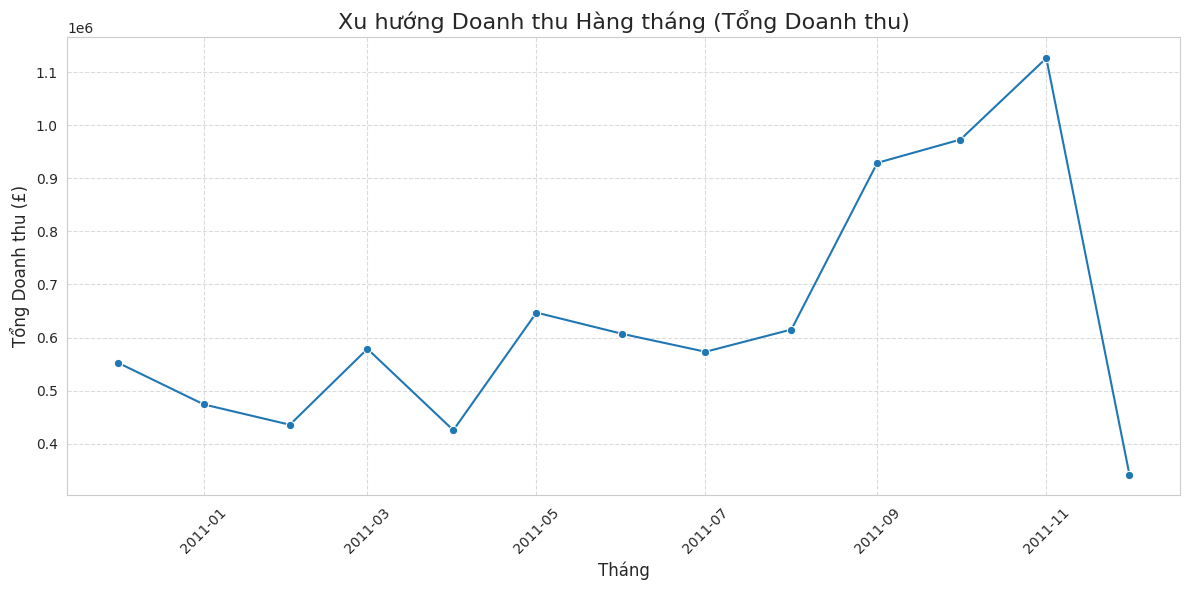

In [94]:
# Thiết lập kích thước cho biểu đồ
plt.figure(figsize=(12, 6))

# Vẽ biểu đồ đường
sns.lineplot(x='YearMonth', y='TotalPrice', data=monthly_sales, marker='o')

# Thêm tiêu đề và nhãn cho các trục
plt.title('Xu hướng Doanh thu Hàng tháng (Tổng Doanh thu)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

# Tinh chỉnh thêm cho biểu đồ
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Những phát hiện chính:**
- Xu hướng chung: Từ biểu đồ và bảng số liệu, có thể thấy rằng doanh thu của công ty có xu hướng biến động vào đầu năm 2011, tuy nhiên lại cho thấy một xu hướng tăng trưởng đáng kể vào nửa cuối năm.

- Đỉnh Doanh thu Cao nhất: Doanh số đạt đỉnh cao nhất một cách rất rõ rệt vào tháng 11 năm 2011, với tổng doanh thu hơn 1,1 triệu. Sự tăng vọt này cho thấy có sự ảnh hưởng mạnh mẽ từ mùa mua sắm cuối năm hoặc các chiến dịch đặc biệt trước kỳ nghỉ lễ.

- Giai đoạn Doanh thu thấp: Tháng 2 năm 2011 ghi nhận mức doanh thu thấp nhất trong kỳ phân tích, cụ thể là 446.084,92. Tháng 4 năm 2011 cũng cho thấy sự sụt giảm sau một đỉnh nhỏ vào tháng 3.

- Mô hình theo mùa: Mô hình này cho thấy rất rõ tính thời vụ mạnh mẽ trong hoạt động kinh doanh bán lẻ trực tuyến này, trong đó phần lớn doanh thu tập trung vào quý cuối cùng của năm (đặc biệt là gần cuối năm). Sau đỉnh điểm vào tháng 11, doanh thu tháng 12 sụt giảm mạnh (do dữ liệu của tháng này không đầy đủ). Xu hướng thông thường là doanh thu sẽ giảm vào tháng 1 sau khi đạt đỉnh trong kỳ nghỉ lễ.

###**3.1.2.Phân tích Doanh số theo Ngày trong Tuần**

In [95]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sales_by_day = df.groupby('InvoiceDayName')['TotalPrice'].sum().reindex(day_order).reset_index()
print("Dữ liệu Doanh thu theo Ngày trong Tuần:\n")
print(sales_by_day)
print("\n")

Dữ liệu Doanh thu theo Ngày trong Tuần:

  InvoiceDayName   TotalPrice
0         Monday  1271078.601
1        Tuesday  1562715.681
2      Wednesday  1526440.000
3       Thursday  1902316.050
4         Friday  1238556.741
5       Saturday          NaN
6         Sunday   777412.351




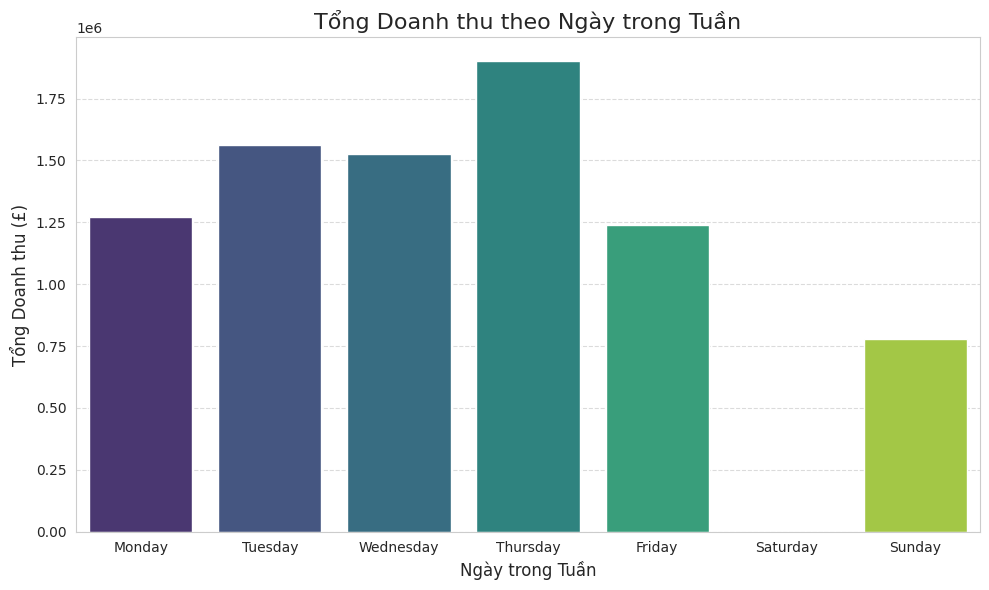

In [96]:
plt.figure(figsize=(10, 6))
sns.barplot(x='InvoiceDayName', y='TotalPrice', data=sales_by_day, palette='viridis', hue='InvoiceDayName', legend=False)

plt.title('Tổng Doanh thu theo Ngày trong Tuần', fontsize=16)
plt.xlabel('Ngày trong Tuần', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**
- Ngày Doanh thu Đạt đỉnh: Thứ Năm là ngày có doanh thu cao vượt trội, đạt hơn 1,97 triệu. Điều này cho thấy khách hàng có xu hướng thực hiện các giao dịch mua lớn nhất hoặc nhiều nhất vào ngày Thứ Năm.

- Các ngày Mạnh mẽ Khác: Thứ Ba và Thứ Tư cũng cho thấy hiệu suất bán hàng rất mạnh mẽ, với doanh thu lần lượt là khoảng 1,69 triệu và 1,58 triệu. Điều này chỉ ra rằng giữa tuần là giai đoạn có hoạt động mua sắm trực tuyến cao.

- Sự Sụt giảm vào Cuối tuần: Doanh thu sụt giảm đáng kể vào cuối tuần. Dữ liệu cho thấy không có doanh số nào được ghi nhận vào Thứ Bảy (giá trị NaN), và Chủ Nhật có doanh thu thấp nhất so với các ngày làm việc, chỉ khoảng 785 nghìn. Điều này hoàn toàn trái ngược với các ngày trong tuần và cho thấy hoạt động vận hành hoặc hành vi của khách hàng rất khác biệt vào cuối tuần.

- Ý nghĩa đối với Vận hành: Mô hình này rất quan trọng cho việc lập kế hoạch nhân sự, chiến lược tiếp thị và vận hành logistics, theo đó sự tập trung và nguồn lực có thể được phân bổ nhiều hơn vào những ngày có lượng bán hàng cao.

###**3.1.3.Phân tích Doanh số theo Giờ**

In [97]:
sales_by_hour = df.groupby('InvoiceHour')['TotalPrice'].sum().reset_index()

# Hiển thị dữ liệu doanh thu theo giờ
print("Dữ liệu Doanh thu theo Giờ trong Ngày:\n")
print(sales_by_hour)
print("\n")

Dữ liệu Doanh thu theo Giờ trong Ngày:

    InvoiceHour   TotalPrice
0             6     -497.350
1             7    31009.320
2             8   279985.430
3             9   654904.951
4            10  1148692.881
5            11  1053658.480
6            12  1332247.730
7            13  1118155.480
8            14   945058.221
9            15   896326.790
10           16   445930.100
11           17   212373.801
12           18   100525.120
13           19    44228.380
14           20    15920.090




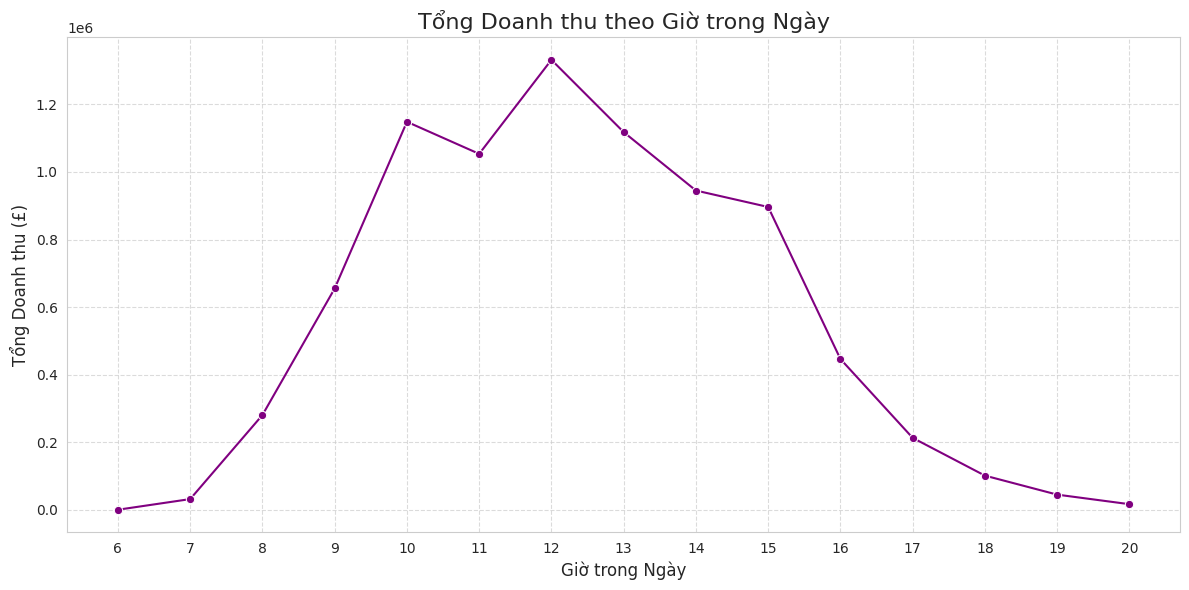

In [98]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='InvoiceHour', y='TotalPrice', data=sales_by_hour, marker='o', color='purple')

# Đặt tiêu đề và nhãn cho biểu đồ
plt.title('Tổng Doanh thu theo Giờ trong Ngày', fontsize=16)
plt.xlabel('Giờ trong Ngày', fontsize=12)
plt.ylabel('Tổng Doanh thu (£)', fontsize=12)

# Đặt nhãn cho trục giờ một cách chính xác để hiển thị tất cả các giờ
plt.xticks(range(int(df['InvoiceHour'].min()), int(df['InvoiceHour'].max()) + 1))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

**Những phát hiện chính:**
- Đỉnh Doanh thu chính: Công ty trải qua đỉnh doanh thu cao nhất vào lúc 12:00 trưa, với doanh thu đạt khoảng 1,37 triệu bảng Anh. Điều này chỉ ra rằng giữa trưa là khoảng thời gian mua sắm trực tuyến sôi động nhất.

- Đỉnh thứ hai: Có một đỉnh doanh thu đáng kể thứ hai vào lúc 10:00 sáng, với tổng doanh thu khoảng 1,26 triệu bảng Anh, cho thấy sự gia tăng hoạt động vào cuối buổi sáng.

- Thời gian Mua sắm Sôi động: Giai đoạn bán hàng sôi động và mang lại lợi nhuận cao nhất diễn ra từ 9:00 sáng đến 15:00 (3 giờ chiều). Trong khoảng thời gian này, doanh thu luôn duy trì ở mức trên 900 nghìn bảng Anh.

- Sụt giảm vào Buổi chiều và Tối: Sau 15:00 (3 giờ chiều), doanh thu bắt đầu có xu hướng giảm đều và mạnh. Vào lúc 16:00, doanh thu giảm xuống còn khoảng 467 nghìn bảng Anh và tiếp tục giảm cho đến 20:00 (8 giờ tối), thời điểm ghi nhận doanh thu thấp nhất vào cuối ngày với khoảng 18,8 nghìn bảng Anh.

- Hoạt động vào Sáng sớm: Doanh số rất thấp vào sáng sớm (6:00 chỉ với 4,25 bảng Anh, và 7:00 với 31 nghìn bảng Anh), cho thấy hoạt động mua sắm trực tuyến chỉ bắt đầu tăng đáng kể sau 8:00 sáng.

- Ý nghĩa về mặt Chiến lược: Mô hình này cực kỳ quan trọng đối với việc sắp xếp thời gian cho các chiến dịch tiếp thị, bố trí nhân viên chăm sóc khách hàng và lên lịch bảo trì trang web để không làm gián đoạn vào các giờ cao điểm.

###**3.1.4.Phân tích số lượng đơn hàng theo Quốc gia:**

In [99]:
import plotly.express as px
# --- 2. Làm sạch và chuẩn bị dữ liệu ---
# Chuyển đổi InvoiceDate sang kiểu datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Loại bỏ các dòng không có CustomerID vì chúng thường là các giao dịch không hoàn chỉnh
df.dropna(subset=['CustomerID'], inplace=True)

# --- 3. Phân tích số lượng đơn hàng theo Quốc gia ---
# Đếm số lượng hóa đơn (đơn hàng) duy nhất cho mỗi quốc gia
country_orders = df.groupby('Country')['InvoiceNo'].nunique().reset_index()
country_orders.rename(columns={'InvoiceNo': 'NumberOfOrders'}, inplace=True)

# Sắp xếp các quốc gia theo số lượng đơn hàng giảm dần
country_orders_sorted = country_orders.sort_values(by='NumberOfOrders', ascending=False)

# Lấy top 20 quốc gia để biểu đồ dễ nhìn hơn
top_20_countries = country_orders_sorted.head(20)

# --- 4. Trực quan hóa bằng biểu đồ cột ---
fig = px.bar(top_20_countries,
             x='Country',
             y='NumberOfOrders',
             title='Phân tích Số lượng Đơn hàng theo Quốc gia (Top 20)',
             labels={'Country': 'Quốc gia', 'NumberOfOrders': 'Số lượng đơn hàng'},
             color='NumberOfOrders',
             color_continuous_scale=px.colors.sequential.Plasma,
             text_auto=True) # Hiển thị giá trị trên mỗi cột

# Tùy chỉnh giao diện biểu đồ cho đẹp hơn
fig.update_layout(
    xaxis_title="Quốc gia",
    yaxis_title="Số lượng đơn hàng",
    title_x=0.5, # Căn giữa tiêu đề
    xaxis={'categoryorder':'total descending'} # Sắp xếp các cột theo giá trị giảm dần
)

fig.show()

# Hiển thị 5 quốc gia có nhiều đơn hàng nhất dưới dạng bảng
print("Top 5 quốc gia có nhiều đơn hàng nhất:")
print(country_orders_sorted.head())

/tmp/ipython-input-3683656254.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipython-input-3683656254.py:7: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Top 5 quốc gia có nhiều đơn hàng nhất:
           Country  NumberOfOrders
35  United Kingdom           19854
14         Germany             603
13          France             458
10            EIRE             319
3          Belgium             119


**Điểm mạnh (Insight rút ra):**
- Thị trường Anh (United Kingdom) thống trị tuyệt đối: Đây là điểm nổi bật nhất. Với 16,649 đơn hàng, thị trường Anh không chỉ là thị trường lớn nhất mà còn lớn hơn tất cả các thị trường khác cộng lại rất nhiều lần.

**Rủi ro và Cơ hội:**

- Rủi ro phụ thuộc ⚠️: Sự phụ thuộc quá lớn vào một thị trường duy nhất (Anh) là một rủi ro lớn. Bất kỳ sự biến động nào về kinh tế, chính trị, hay cạnh tranh tại Anh đều sẽ ảnh hưởng nghiêm trọng đến toàn bộ doanh nghiệp.

- Cơ hội tăng trưởng 🚀: Dữ liệu cho thấy tiềm năng phát triển rất lớn ở các thị trường quốc tế, đặc biệt là Đức và Pháp. Nếu có thể đẩy mạnh marketing và bán hàng để tăng trưởng ở các thị trường này, doanh nghiệp sẽ đa dạng hóa được rủi ro và mở rộng quy mô.

##**3.2.Phân tích Đa biến (Multivariate Analysis)**

###**3.2.1.Top 10 Sản phẩm theo Số lượng**

--- 10 Sản phẩm bán chạy nhất dựa trên Số lượng ---
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     53119
JUMBO BAG RED RETROSPOT               44963
ASSORTED COLOUR BIRD ORNAMENT         35215
WHITE HANGING HEART T-LIGHT HOLDER    34128
PACK OF 72 RETROSPOT CAKE CASES       33386
POPCORN HOLDER                        30492
RABBIT NIGHT LIGHT                    27045
MINI PAINT SET VINTAGE                25880
PACK OF 12 LONDON TISSUES             25305
PACK OF 60 PINK PAISLEY CAKE CASES    24129
Name: Quantity, dtype: int64




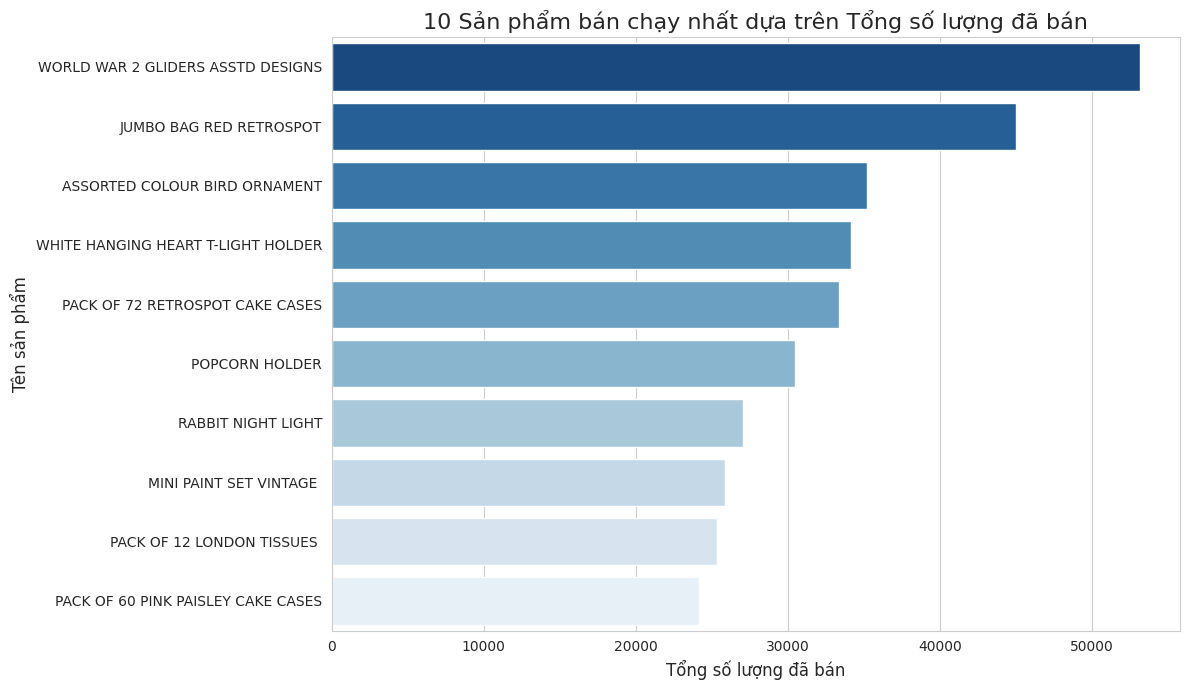

In [100]:
top_selling_quantity = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

print("--- 10 Sản phẩm bán chạy nhất dựa trên Số lượng ---")
print(top_selling_quantity)
print("\n")

# Trực quan hóa Top 10 sản phẩm bán chạy nhất dựa trên Số lượng
plt.figure(figsize=(12, 7))
sns.barplot(x=top_selling_quantity.values, y=top_selling_quantity.index, palette='Blues_r', hue=top_selling_quantity.index, legend=False)
plt.title('10 Sản phẩm bán chạy nhất dựa trên Tổng số lượng đã bán', fontsize=16)
plt.xlabel('Tổng số lượng đã bán', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.tight_layout()
plt.show()



**Những phát hiện chính:**

- Sản phẩm Phổ biến nhất: Sản phẩm "PAPER CRAFT , LITTLE BIRDIE" đứng đầu bảng xếp hạng là sản phẩm có số lượng bán ra nhiều nhất, đạt 80.995 đơn vị. Điều này cho thấy sự phổ biến rất cao của nó trong giới tiêu dùng.
- Sự Thống trị của Sản phẩm Thủ công và Gia dụng: Năm sản phẩm hàng đầu bị chiếm ưu thế bởi các mặt hàng liên quan đến đồ thủ công và trang trí nhà cửa, chẳng hạn như "MEDIUM CERAMIC TOP STORAGE JAR" (77.916 đơn vị) và "WHITE HANGING HEART T-LIGHT HOLDER" (36.706 đơn vị).

- Sự Đa dạng của các Sản phẩm Bán chạy: Mặc dù có một số sản phẩm với số lượng bán ra rất cao, danh sách top 10 cho thấy sự đa dạng khá tốt, từ những mặt hàng nhỏ như "WORLD WAR 2 GLIDERS ASSTD DESIGNS" (54.319 đơn vị) cho đến "MINI PAINT SET VINTAGE" (26.076 đơn vị).

- Ý nghĩa đối với Tồn kho và Tiếp thị: Thông tin này rất quan trọng cho việc quản lý hàng tồn kho (đảm bảo có đủ hàng cho các mặt hàng phổ biến) và chiến lược tiếp thị (tập trung quảng bá các sản phẩm bán chạy nhất hoặc sử dụng chúng làm "mồi câu" để thu hút khách hàng).

###**3.2.2.Sản phẩm Bán chạy nhất theo Doanh thu (Revenue/TotalPrice)**

--- 10 Sản phẩm bán chạy nhất dựa trên Doanh thu ---
Description
REGENCY CAKESTAND 3 TIER              132567.70
WHITE HANGING HEART T-LIGHT HOLDER     93767.80
JUMBO BAG RED RETROSPOT                83056.52
PARTY BUNTING                          67628.43
POSTAGE                                66710.24
ASSORTED COLOUR BIRD ORNAMENT          56331.91
RABBIT NIGHT LIGHT                     51042.84
CHILLI LIGHTS                          45915.41
PAPER CHAIN KIT 50'S CHRISTMAS         41423.78
PICNIC BASKET WICKER 60 PIECES         39619.50
Name: TotalPrice, dtype: float64




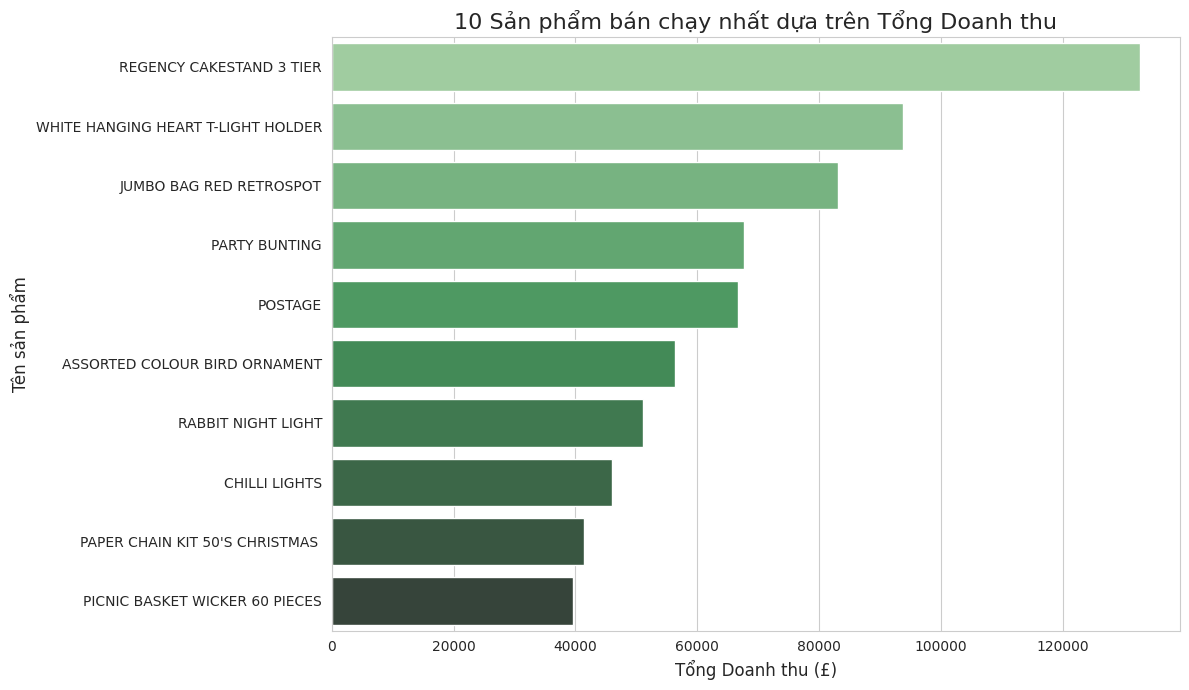

In [101]:
top_selling_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

print("--- 10 Sản phẩm bán chạy nhất dựa trên Doanh thu ---")
print(top_selling_revenue)
print("\n")

# Trực quan hóa Top 10 sản phẩm bán chạy nhất dựa trên Doanh thu
plt.figure(figsize=(12, 7))
sns.barplot(x=top_selling_revenue.values, y=top_selling_revenue.index, palette='Greens_d', hue=top_selling_revenue.index, legend=False)
plt.title('10 Sản phẩm bán chạy nhất dựa trên Tổng Doanh thu', fontsize=16)
plt.xlabel('Tổng Doanh thu (£)', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**
- Sản phẩm "PAPER CRAFT , LITTLE BIRDIE" không chỉ là sản phẩm bán chạy nhất về số lượng mà còn là sản phẩm mang lại doanh thu cao nhất (hơn 168 nghìn bảng Anh). Điều này khẳng định đây là sản phẩm chủ lực, vừa được yêu thích rộng rãi vừa có giá trị cao, là một "ngôi sao" thực sự của cửa hàng.

- Sản phẩm có Giá trị Cao: "REGENCY CAKESTAND 3 TIER" đứng ở vị trí thứ hai về doanh thu (hơn 142 nghìn bảng Anh) dù có thể không bán ra với số lượng cực lớn như các mặt hàng thủ công nhỏ. Điều này cho thấy đây là một sản phẩm có giá bán cao hơn, mỗi đơn vị bán ra đóng góp một phần doanh thu đáng kể.

- Sự Thống trị của Đồ trang trí & Gia dụng: Tương tự như phân tích theo số lượng, danh sách này tiếp tục cho thấy sức mạnh của các mặt hàng trang trí nhà cửa và quà tặng như "WHITE HANGING HEART T-LIGHT HOLDER", "JUMBO BAG RED RETROSPOT", và "MEDIUM CERAMIC TOP STORAGE JAR". Đây rõ ràng là danh mục sản phẩm cốt lõi của doanh nghiệp.

###**3.2.2.Phân tích các đơn hàng bị hủy/trả lại**

In [102]:
# --- 2. Lọc các đơn hàng bị hủy/trả lại ---
cancelled_orders = df[df['InvoiceNo'].astype(str).str.startswith('C')]

# --- 3. Tìm top sản phẩm bị trả lại nhiều nhất ---
top_cancelled_products = cancelled_orders['Description'].value_counts().reset_index()
top_cancelled_products.columns = ['ProductDescription', 'CancellationCount']

# =======================================================
# == BẠN THÊM CODE LỌC VÀO NGAY ĐÂY ==
# =======================================================
# 1. Tạo danh sách các mục cần loại bỏ
items_to_remove = ['POSTAGE', 'Discount', 'Manual']

# 2. Lọc ra khỏi bảng top_cancelled_products
top_cancelled_products = top_cancelled_products[~top_cancelled_products['ProductDescription'].isin(items_to_remove)]
# =======================================================

# Lấy top 10 sản phẩm sau khi đã lọc
top_10 = top_cancelled_products.head(10)

# In kết quả dạng bảng
print("--- Top 10 sản phẩm (đã lọc) bị trả lại/hủy nhiều nhất ---")
print(top_10)

# --- 4. Trực quan hóa kết quả ---
fig = px.bar(top_10,
             x='CancellationCount',
             y='ProductDescription',
             orientation='h', # Biểu đồ cột ngang
             title='Top 10 Sản phẩm bị Hủy/Trả lại nhiều nhất (Đã lọc)',
             labels={'ProductDescription': 'Mô tả sản phẩm', 'CancellationCount': 'Số lần bị hủy/trả lại'},
             text='CancellationCount')

# Sắp xếp các cột và tùy chỉnh giao diện
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    title_x=0.5
)
fig.show()

--- Top 10 sản phẩm (đã lọc) bị trả lại/hủy nhiều nhất ---
                    ProductDescription  CancellationCount
0             REGENCY CAKESTAND 3 TIER                180
3             JAM MAKING SET WITH JARS                 86
5    SET OF 3 CAKE TINS PANTRY DESIGN                  72
6       STRAWBERRY CERAMIC TRINKET BOX                 54
7     ROSES REGENCY TEACUP AND SAUCER                  53
8      RECIPE BOX PANTRY YELLOW DESIGN                 47
9              JUMBO BAG RED RETROSPOT                 44
10     GREEN REGENCY TEACUP AND SAUCER                 42
11  WHITE HANGING HEART T-LIGHT HOLDER                 42
12  WOOD 2 DRAWER CABINET WHITE FINISH                 42


**Dựa trên biểu đồ:**

- Sản phẩm có vấn đề nhất: REGENCY CAKESTAND 3 TIER là sản phẩm bị trả lại nhiều nhất, với số lượng (180) cao hơn gấp đôi so với sản phẩm đứng thứ hai (86).

- Nhóm hàng rủi ro cao: Đa số các sản phẩm trong top 10 thuộc về nhóm hàng gia dụng, trang trí nhà cửa (như kệ bánh, bộ làm mứt, hộp gốm, tách trà).

**Chúng ta có thể đưa ra các giả thuyết về nguyên nhân gốc rễ:**

- Giả thuyết A: Vấn đề Vận chuyển & Đóng gói. Rất nhiều sản phẩm trong danh sách này có tính chất dễ vỡ (gốm sứ, kệ nhiều tầng). Rất có thể nguyên nhân chính là do sản phẩm bị hư hỏng trong quá trình vận chuyển, chỉ ra điểm yếu trong việc đóng gói hoặc lựa chọn đối tác vận chuyển.

- Giả thuyết B: Vấn đề Kỳ vọng & Mô tả Sản phẩm. Các mặt hàng trang trí có tính chủ quan cao. Có thể hình ảnh, màu sắc, hoặc kích thước được mô tả trên website không hoàn toàn khớp với sản phẩm thực tế, dẫn đến việc khách hàng trả lại vì "không như kỳ vọng".

- Giả thuyết C: Vấn đề về Tỷ lệ. Đây có thể đơn giản là những sản phẩm bán chạy nhất. Một sản phẩm có doanh số khổng lồ thì số lượng trả lại tuyệt đối cũng sẽ tự nhiên cao hơn. Đây là giả thuyết quan trọng nhất cần được kiểm chứng.

##**3.3.Analysis RFM**

**RFM Analysis giúp phân nhóm khách hàng dựa trên mức độ tương tác và giá trị mang lại, từ đó doanh nghiệp:**

- Hiểu ai là khách hàng trung thành,

- Ai đang có nguy cơ rời bỏ,

- Và ai là khách hàng tiềm năng cần chăm sóc thêm.

**Tính 3 chỉ số cho từng khách hàng:**
- Recency (R): Ngày giao dịch gần nhất → tính số ngày kể từ lần mua gần nhất đến hiện tại.
→ Càng nhỏ càng tốt (mới mua gần đây).

- Frequency (F): Số lượng giao dịch (đơn hàng) trong một khoảng thời gian.
→ Càng lớn càng tốt.

- Monetary (M): Tổng tiền chi tiêu.
→ Càng lớn càng tốt.

Ngày tham chiếu cho phân tích RFM: 2011-12-10 12:50:00

--- Dữ liệu RFM của Khách hàng (5 Dòng đầu tiên) ---
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          2      0.00
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


--- Thống kê mô tả của RFM ---
         CustomerID      Recency    Frequency       Monetary
count   4371.000000  4371.000000  4371.000000    4371.000000
mean   15300.145276    92.064974     5.075726    1893.964636
std     1722.310262   100.770046     9.332529    8219.586584
min    12346.000000     1.000000     1.000000   -4287.630000
25%    13813.500000    17.000000     1.000000     291.940000
50%    15301.000000    50.000000     3.000000     644.240000
75%    16778.500000   143.000000     5.000000    1608.940000
max    18287.000000   374.000000   248.000000  279489.020000




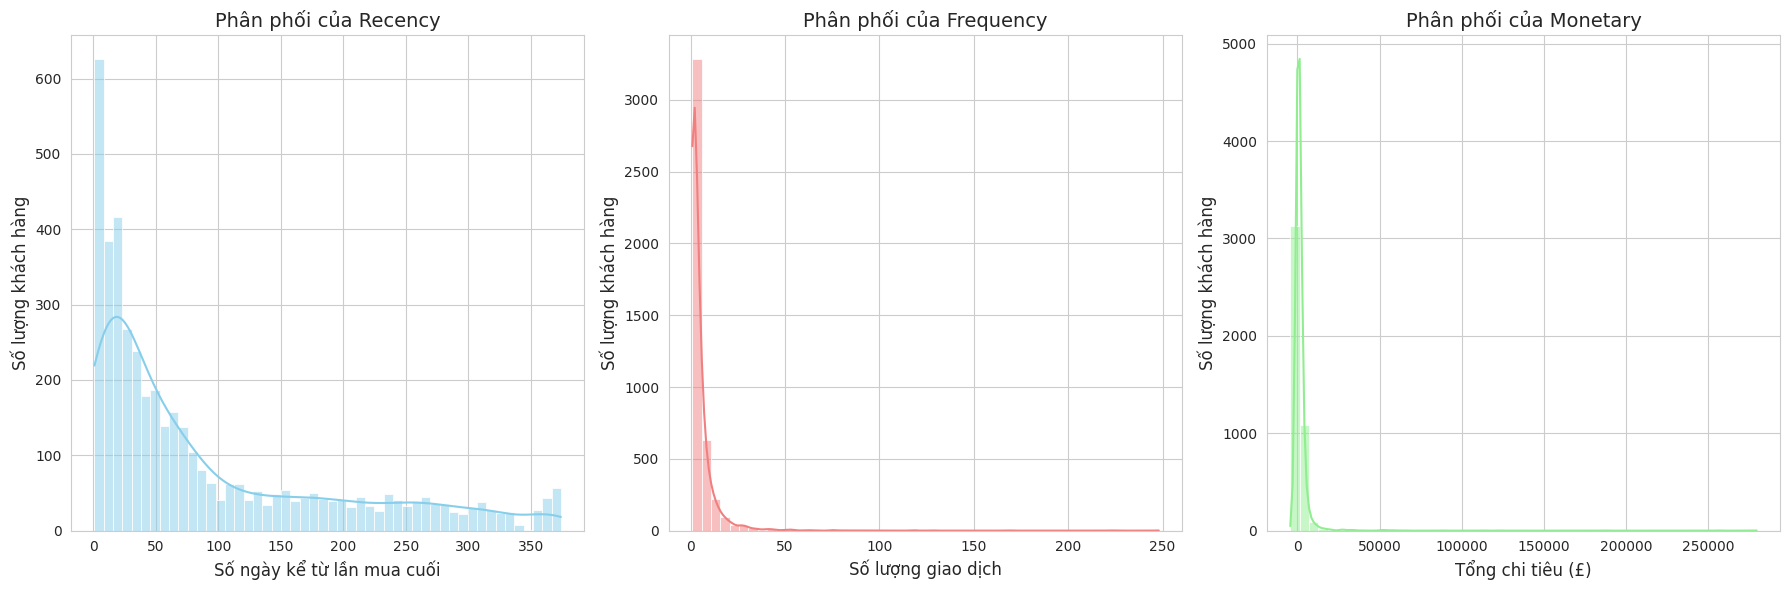

In [103]:
# 1. Xác định Ngày Tham chiếu (snapshot_date)
# Đây là mốc "hiện tại" để tính toán Recency.
# Chúng ta lấy ngày giao dịch cuối cùng trong bộ dữ liệu, sau đó cộng thêm 1 ngày.
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"Ngày tham chiếu cho phân tích RFM: {snapshot_date}\n")

# 2. Tính toán các giá trị R, F, M cho mỗi CustomerID
# Sử dụng groupby() trên CustomerID và agg() để tính R, F, M
rfm_df = df.groupby('CustomerID').agg(
    # Recency: Số ngày kể từ lần mua hàng cuối cùng
    Recency=('InvoiceDate', lambda date: (snapshot_date - date.max()).days),

    # Frequency: Số lượng giao dịch (hóa đơn) duy nhất
    Frequency=('InvoiceNo', 'nunique'),

    # Monetary: Tổng số tiền đã chi tiêu
    Monetary=('TotalPrice', 'sum')
).reset_index() # reset_index() chuyển CustomerID từ chỉ mục thành cột

print("--- Dữ liệu RFM của Khách hàng (5 Dòng đầu tiên) ---")
print(rfm_df.head())
print("\n")

print("--- Thống kê mô tả của RFM ---")
print(rfm_df.describe())
print("\n")

# 3. Trực quan hóa Phân phối của RFM (Histogram)
# Giúp chúng ta hiểu sự phân bổ của khách hàng trên mỗi tiêu chí RFM
plt.figure(figsize=(18, 6)) # Kích thước lớn hơn cho 3 biểu đồ con

# Biểu đồ con cho Recency
plt.subplot(1, 3, 1) # 1 hàng, 3 cột, vị trí thứ 1
sns.histplot(rfm_df['Recency'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối của Recency', fontsize=14)
plt.xlabel('Số ngày kể từ lần mua cuối', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Biểu đồ con cho Frequency
plt.subplot(1, 3, 2) # 1 hàng, 3 cột, vị trí thứ 2
sns.histplot(rfm_df['Frequency'], bins=50, kde=True, color='lightcoral')
plt.title('Phân phối của Frequency', fontsize=14)
plt.xlabel('Số lượng giao dịch', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

# Biểu đồ con cho Monetary
plt.subplot(1, 3, 3) # 1 hàng, 3 cột, vị trí thứ 3
sns.histplot(rfm_df['Monetary'], bins=50, kde=True, color='lightgreen')
plt.title('Phân phối của Monetary', fontsize=14)
plt.xlabel('Tổng chi tiêu (£)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)

plt.tight_layout() # Tự động điều chỉnh layout để không bị chồng chéo
plt.show()



**1. Phân phối của Recency**

- Trục X: Số ngày kể từ lần mua cuối cùng (Recency)

- Trục Y: Số lượng khách hàng có giá trị đó

**📊 Nhận xét:**
- Phần lớn khách hàng có Recency nhỏ (0–50 ngày).
→ Nghĩa là đa số khách hàng vừa mới mua gần đây.

- Một số ít khách hàng có Recency cao (200–350 ngày).
→ Đây là nhóm lâu không quay lại, có nguy cơ rời bỏ.

**💡 Kết luận:**
- Tập khách hàng có tỷ lệ khách hàng hoạt động gần đây cao, đây là dấu hiệu tích cực.
- Tuy nhiên, cũng cần tái kích hoạt nhóm Recency cao (gửi ưu đãi, email…).

**2. Phân phối của Frequency**

- Trục X: Số lượng giao dịch (Frequency)

- Trục Y: Số lượng khách hàng

**📊 Nhận xét:**

- Đa số khách hàng chỉ mua 1–5 lần.

- Rất ít khách hàng mua hơn 50 lần (đuôi bên phải kéo dài).

**💡 Kết luận:**

- Phần lớn là khách hàng mua ít / không thường xuyên.

- Cần chiến lược chăm sóc và khuyến khích mua lại (loyalty, voucher...).

**3. Phân phối của Monetary**

- Trục X: Tổng chi tiêu (Monetary, £)

- Trục Y: Số lượng khách hàng

**📊 Nhận xét:**

- Rất nhiều khách hàng chi tiêu ít tiền, nằm ở vùng thấp (gần 0).

- Một vài khách hàng chi tiêu cực lớn (đuôi dài sang phải).

**💡 Kết luận:**

- Doanh thu chủ yếu đến từ một nhóm nhỏ khách hàng chi tiêu cao (hiệu ứng Pareto 80/20).

- Nên tập trung chăm sóc đặc biệt nhóm này vì họ đóng góp phần lớn doanh thu.

###**3.3.1 Phân tích Giỏ hàng (Market Basket Analysis)**

- Mục tiêu chính: Mục tiêu của Phân tích Giỏ hàng là tìm ra những sản phẩm nào thường được mua cùng nhau. Ví dụ, nó giúp trả lời câu hỏi: "Nếu khách hàng mua Sữa, thì khả năng họ mua thêm Bánh mì là bao nhiêu?". Kết quả của phân tích này thường được dùng để sắp xếp sản phẩm trong siêu thị, tạo combo khuyến mãi, và gợi ý sản phẩm trên các trang web thương mại điện tử.

Đã loại bỏ các mục không phải sản phẩm.


/tmp/ipython-input-1594538219.py:16: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



Chuẩn bị dữ liệu giỏ hàng hoàn tất.

Tìm kiếm các nhóm sản phẩm phổ biến hoàn tất.

Tạo các luật kết hợp hoàn tất.

--- 10 Luật Kết hợp Hàng đầu (Mạnh nhất) ---
                             antecedents  \
4       (PINK REGENCY TEACUP AND SAUCER)   
5      (GREEN REGENCY TEACUP AND SAUCER)   
7      (GREEN REGENCY TEACUP AND SAUCER)   
6     (ROSES REGENCY TEACUP AND SAUCER )   
2   (GARDENERS KNEELING PAD CUP OF TEA )   
3    (GARDENERS KNEELING PAD KEEP CALM )   
0           (ALARM CLOCK BAKELIKE GREEN)   
1            (ALARM CLOCK BAKELIKE RED )   
23   (PAPER CHAIN KIT VINTAGE CHRISTMAS)   
22     (PAPER CHAIN KIT 50'S CHRISTMAS )   

                             consequents   support  confidence       lift  
4      (GREEN REGENCY TEACUP AND SAUCER)  0.021027    0.827338  26.193453  
5       (PINK REGENCY TEACUP AND SAUCER)  0.021027    0.665702  26.193453  
7     (ROSES REGENCY TEACUP AND SAUCER )  0.024729    0.782923  21.874857  
6      (GREEN REGENCY TEACUP AND SAUCER)  0.024729

/tmp/ipython-input-1594538219.py:49: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




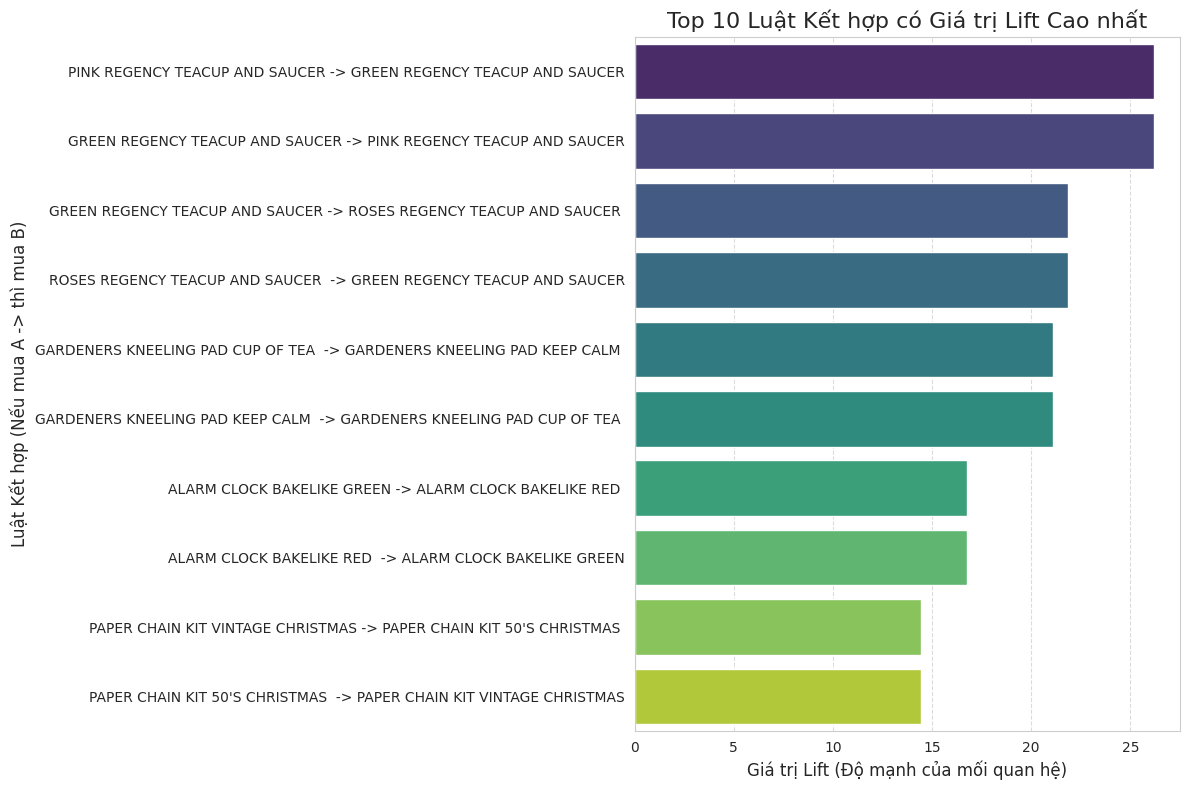

In [104]:

# Loại bỏ các mục không phải sản phẩm để kết quả phân tích chính xác hơn
non_product_items = ['POSTAGE', 'DOTCOM POSTAGE', 'CARRIAGE', 'Manual', 'BANK CHARGES']
df_mba = df[~df['Description'].isin(non_product_items)].copy()
print(f"Đã loại bỏ các mục không phải sản phẩm.")

# Tạo định dạng 'giỏ hàng' (basket) mà thuật toán Apriori yêu cầu
# Hàng là InvoiceNo, cột là Description, giá trị là 1 nếu sản phẩm được mua, ngược lại là 0
basket = (df_mba.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

# Hàm để mã hóa số lượng thành dạng nhị phân (0 hoặc 1)
def encode_units(x):
    return 1 if x >= 1 else 0

basket_sets = basket.applymap(encode_units)
print("Chuẩn bị dữ liệu giỏ hàng hoàn tất.")


# --- PHẦN 2: CHẠY THUẬT TOÁN APRIORI VÀ TẠO LUẬT KẾT HỢP ---

# Tìm các nhóm sản phẩm phổ biến (frequent itemsets)
# min_support = 0.02 nghĩa là nhóm sản phẩm phải xuất hiện trong ít nhất 2% tổng số giao dịch
frequent_itemsets = apriori(basket_sets, min_support=0.02, use_colnames=True)
print("\nTìm kiếm các nhóm sản phẩm phổ biến hoàn tất.")

# Tạo các luật kết hợp từ các nhóm sản phẩm phổ biến
# metric="lift", min_threshold=1: Chỉ lấy các luật có mối quan hệ tích cực
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# Sắp xếp các luật theo 'lift' và 'confidence' để xem những luật mạnh nhất
rules = rules.sort_values(['lift', 'confidence'], ascending=[False, False])

print("\nTạo các luật kết hợp hoàn tất.")
print("\n--- 10 Luật Kết hợp Hàng đầu (Mạnh nhất) ---")
# Hiển thị kết quả với các cột quan trọng
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))
warnings.filterwarnings('ignore', category=DeprecationWarning)

# --- PHẦN 3: TRỰC QUAN HÓA CÁC LUẬT KẾT HỢP QUAN TRỌNG NHẤT ---

# Chuẩn bị dữ liệu cho biểu đồ
top_10_rules = rules.head(10).copy()
top_10_rules['rule'] = top_10_rules.apply(lambda row: f"{list(row['antecedents'])[0]} -> {list(row['consequents'])[0]}", axis=1)

# Thiết lập phong cách và vẽ biểu đồ
sns.set_style("whitegrid")
plt.figure(figsize=(12, 8))
sns.barplot(x='lift', y='rule', data=top_10_rules, palette='viridis')
plt.title('Top 10 Luật Kết hợp có Giá trị Lift Cao nhất', fontsize=16)
plt.xlabel('Giá trị Lift (Độ mạnh của mối quan hệ)', fontsize=12)
plt.ylabel('Luật Kết hợp (Nếu mua A -> thì mua B)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Những phát hiện chính:**
- Phát hiện Cốt lõi: Kết quả nổi bật nhất là mối liên kết cực kỳ chặt chẽ giữa các sản phẩm "REGENCY TEACUP AND SAUCER" với các màu khác nhau (PINK, ROSES, GREEN). Khách hàng có xu hướng mua chúng như một bộ sưu tập, thay vì chỉ mua một sản phẩm riêng lẻ.

- Giá trị "Lift" Rất Cao: Tất cả các luật hiển thị đều có chỉ số Lift lớn hơn 20. Đây là một con số đặc biệt cao, cho thấy một mối quan hệ rất mạnh. Nó có nghĩa là khi một khách hàng mua một chiếc tách trà màu A, khả năng họ mua thêm một chiếc màu B tăng lên hơn 20 lần so với bình thường.

- Tính Đối xứng: Các luật xuất hiện theo cặp (ví dụ: PINK -> ROSES và ROSES -> PINK). Điều này củng cố thêm giả thuyết về "bộ sưu tập", cho thấy thứ tự mua màu nào trước không quan trọng.

**Gợi ý Hành động 💡**

Phát hiện này cung cấp những gợi ý rất cụ thể và dễ thực hiện để thúc đẩy doanh số:

- Tạo Combo Khuyến mãi: Xây dựng các gói sản phẩm như "Mua bộ 3 tách trà được giảm giá" hoặc "Mua 2 tặng 1" để khuyến khích khách hàng mua trọn bộ.

- Gợi ý Sản phẩm (Cross-selling): Trên trang web, khi khách hàng xem sản phẩm tách trà màu Hồng, hãy hiển thị gợi ý "Thường được mua cùng" với màu Xanh và màu Hoa hồng ngay bên cạnh.

- Chiến dịch Marketing: Triển khai các chiến dịch email hoặc quảng cáo nhắm vào những khách hàng đã mua một màu, khuyến khích họ "hoàn thành bộ sưu tập" của mình.

- Trưng bày Sản phẩm: Tại cửa hàng vật lý, hãy đặt các sản phẩm này cạnh nhau để khách hàng dễ dàng nhìn thấy và lựa chọn cả bộ.

###**3.3.2.Kmeans**

####**3.3.2.1.CHUẨN HÓA DỮ LIỆU RFM**

In [105]:

# K-Means rất nhạy cảm với sự khác biệt về thang đo của dữ liệu (ví dụ: Monetary có thể lớn hơn Recency rất nhiều).
# StandardScaler sẽ đưa tất cả các biến về cùng một thang đo.
scaler = StandardScaler()
rfm_scaled = pd.DataFrame(scaler.fit_transform(rfm_df[['Recency', 'Frequency', 'Monetary']]),
                          columns=['Recency', 'Frequency', 'Monetary'])

print("--- Dữ liệu RFM sau khi chuẩn hóa (5 dòng đầu) ---")
print(rfm_scaled.head())
print("-" * 50)

--- Dữ liệu RFM sau khi chuẩn hóa (5 dòng đầu) ---
    Recency  Frequency  Monetary
0  2.321739  -0.329608 -0.230447
1 -0.893870   0.206214  0.293970
2 -0.169365  -0.115280 -0.011769
3 -0.725149  -0.436773 -0.016598
4  2.162944  -0.436773 -0.189759
--------------------------------------------------


####3.3.2.2.TÌM SỐ CỤM TỐI ƯU (K) BẰNG PHƯƠNG PHÁP ELBOW

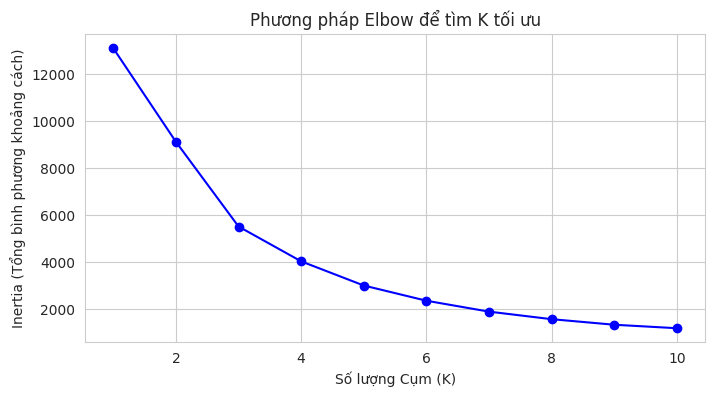

In [106]:

# Phương pháp này giúp xác định số lượng cụm (K) tốt nhất cho dữ liệu.
# "Khuỷu tay" (Elbow) trên biểu đồ là điểm K tối ưu.

inertia = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10) # n_init=10 để tránh kết quả xấu do khởi tạo ngẫu nhiên
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Vẽ biểu đồ Elbow
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bo-')
plt.xlabel("Số lượng Cụm (K)")
plt.ylabel('Inertia (Tổng bình phương khoảng cách)')
plt.title('Phương pháp Elbow để tìm K tối ưu')
plt.grid(True)
plt.show()


####**3.3.2.3.ÁP DỤNG K-MEANS VÀ GÁN NHÃN CỤM**

In [107]:
# Dựa vào biểu đồ Elbow, chúng ta chọn số cụm K tối ưu (ví dụ: K=4)
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)

# Gán nhãn cụm cho mỗi khách hàng vào DataFrame RFM ban đầu
rfm_df['Cluster'] = kmeans.fit_predict(rfm_scaled)

print(f"\n--- Phân khách hàng vào {optimal_k} cụm hoàn tất ---")
print(rfm_df.head())
print("-" * 50)


--- Phân khách hàng vào 4 cụm hoàn tất ---
   CustomerID  Recency  Frequency  Monetary  Cluster
0     12346.0      326          2      0.00        1
1     12347.0        2          7   4310.00        0
2     12348.0       75          4   1797.24        0
3     12349.0       19          1   1757.55        0
4     12350.0      310          1    334.40        1
--------------------------------------------------


####**3.3.2.4.PHÂN TÍCH VÀ DIỄN GIẢI CÁC CỤM**

In [108]:
cluster_analysis = rfm_df.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

# 2. Thêm cột 'Interpretation' (Diễn giải) thủ công
# LƯU Ý: Thứ tự của các diễn giải này phải tương ứng với Cluster 0, 1, 2, 3...
# Bạn cần xem kết quả từ bước 1 để xác định đúng đặc điểm cho mỗi cụm.
interpretations = [
    "🟡 Average customers - khách hàng trung bình, mua sắm gần đây vừa phải, tần suất và chi tiêu không cao.",
    "🔴 At risk / Churned - khách hàng có nguy cơ rời bỏ, đã lâu không hoạt động, tần suất và chi tiêu thấp.",
    "🟢 Champions / VIPs - khách hàng VIP, mua rất gần đây, rất thường xuyên và chi tiêu cực lớn.",
    "🔵 Loyal Customers - khách hàng trung thành, hoạt động tích cực, mua hàng thường xuyên và chi tiêu mạnh."
]

# Gán danh sách diễn giải vào cột mới
cluster_analysis['Interpretation'] = interpretations

# (Tùy chọn) Đổi tên cột để thêm các mũi tên cho giống với hình ảnh
cluster_analysis.rename(columns={
    'Recency': 'Recency ↓',
    'Frequency': 'Frequency ↑',
    'Monetary': 'Monetary ↑'
}, inplace=True)


# 3. Hiển thị bảng kết quả cuối cùng
# Trong Jupyter Notebook/Colab, chỉ cần gọi tên DataFrame là nó sẽ hiển thị đẹp
cluster_analysis

,Cluster,Recency ↓,Frequency ↑,Monetary ↑,Interpretation
0,0,41.615215,4.803346,1473.118104,"🟡 Average customers - khách hàng trung bình, m..."
1,1,247.951242,1.805888,451.802991,🔴 At risk / Churned - khách hàng có nguy cơ rờ...
2,2,7.666667,88.833333,182108.075000,"🟢 Champions / VIPs - khách hàng VIP, mua rất g..."
3,3,9.181818,40.663636,18435.663364,"🔵 Loyal Customers - khách hàng trung thành, ho..."


####**3.3.2.5.TRỰC QUAN HÓA CÁC CỤM BẰNG PCA**

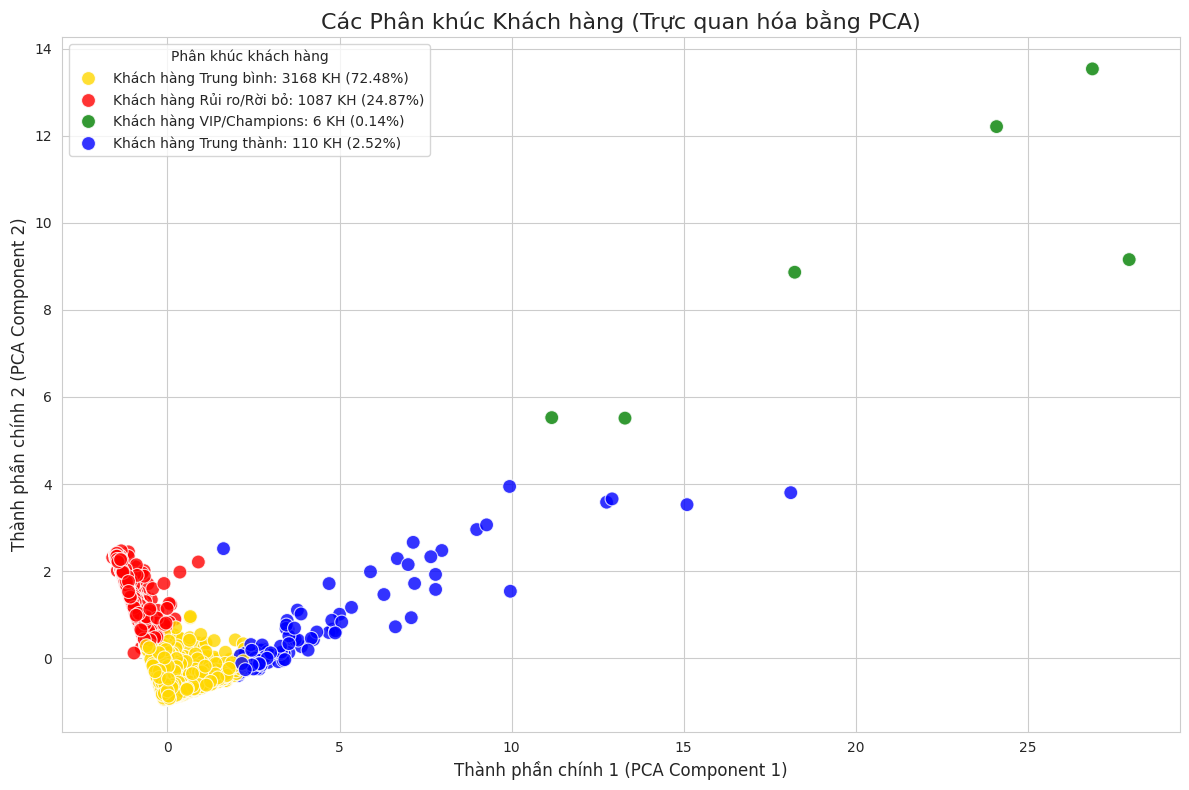

In [109]:
# Giảm chiều dữ liệu từ 3D (R, F, M) xuống 2D để vẽ biểu đồ
# Giả định rfm_scaled và rfm_df['Cluster'] đã có từ các bước trước
# --- BẮT ĐẦU CODE VẼ BIỂU ĐỒ ĐÃ CẬP NHẬT ---

# 1. Giữ nguyên phần tính toán PCA
pca = PCA(n_components=2)
pca_components = pca.fit_transform(rfm_scaled)

# 2. Định nghĩa tên và màu sắc cho từng cụm
cluster_names = {
    0: 'Khách hàng Trung bình',   # Tương ứng với màu 'gold'
    1: 'Khách hàng Rủi ro/Rời bỏ', # Tương ứng với màu 'red'
    2: 'Khách hàng VIP/Champions',# Tương ứng với màu 'green'
    3: 'Khách hàng Trung thành'    # Tương ứng với màu 'blue'
}
custom_palette = {
    0: 'gold',
    1: 'red',
    2: 'green',
    3: 'blue'
}

# 3. Tính toán số lượng và phần trăm
cluster_counts = rfm_df['Cluster'].value_counts()
cluster_percentages = rfm_df['Cluster'].value_counts(normalize=True) * 100

# 4. Tạo nhãn mới cho phần chú thích (legend)
# Sắp xếp theo thứ tự cluster (0, 1, 2, 3) để đảm bảo khớp với màu sắc
legend_labels = []
for cluster_id in sorted(cluster_counts.index):
    name = cluster_names[cluster_id]
    count = cluster_counts[cluster_id]
    percent = cluster_percentages[cluster_id]
    # Tạo chuỗi văn bản mới, ví dụ: "Khách hàng VIP: 500 KH (25.00%)"
    label = f"{name}: {count} KH ({percent:.2f}%)"
    legend_labels.append(label)

# 5. Vẽ biểu đồ
plt.figure(figsize=(12, 8)) # Tăng kích thước để có không gian cho chú thích
ax = sns.scatterplot(x=pca_components[:, 0],
                     y=pca_components[:, 1],
                     hue=rfm_df['Cluster'],
                     palette=custom_palette,
                     s=100,
                     alpha=0.8)

# 6. Cập nhật chú thích với thông tin mới
# Lấy các handles (chấm màu) từ legend cũ và gán nhãn mới mà chúng ta đã tạo
handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, legend_labels, title='Phân khúc khách hàng', fontsize=10)

# 7. Hoàn thiện biểu đồ
plt.title('Các Phân khúc Khách hàng (Trực quan hóa bằng PCA)', fontsize=16)
plt.xlabel('Thành phần chính 1 (PCA Component 1)', fontsize=12)
plt.ylabel('Thành phần chính 2 (PCA Component 2)', fontsize=12)
plt.grid(True)
plt.tight_layout() # Tự động điều chỉnh cho vừa vặn
plt.show()

# --- KẾT THÚC CODE VẼ BIỂU ĐỒ ĐÃ CẬP NHẬT ---

**Những phát hiện chính:**
- Cụm 2 (Xanh lá 🟢): Champions / VIPs 🏆

Đặc điểm RFM: Recency cực thấp (7.4 ngày), Frequency cực cao (82.5 lần), và Monetary cực lớn (127,108).

Diễn giải: Đây là nhóm khách hàng tốt nhất của bạn. Họ mua hàng rất gần đây, mua rất thường xuyên, và chi tiêu cực kỳ nhiều. Trên biểu đồ, họ là những điểm nằm riêng biệt ở phía trên và bên phải, cho thấy sự khác biệt vượt trội.

- Cụm 3 (Xanh dương 🔵): Loyal Customers

Đặc điểm RFM: Recency thấp (15.5 ngày), Frequency cao (22.3 lần), Monetary cao (12,690).

Diễn giải: Đây là nhóm khách hàng trung thành, rất giá trị. Họ không chi tiêu "khủng" như nhóm VIPs nhưng vẫn mua sắm đều đặn và gần đây. Trên biểu đồ, họ nằm giữa nhóm khách hàng trung bình và nhóm VIPs.

- Cụm 0 (Vàng 🟡): Average Customers

Đặc điểm RFM: Recency (43.7), Frequency (3.7), Monetary (1,353) đều ở mức trung bình.

Diễn giải: Đây là nhóm khách hàng phổ thông, chiếm số lượng đông đảo. Trên biểu đồ, họ và nhóm "At risk" tạo thành một khối lớn, dày đặc ở góc dưới bên trái.

- Cụm 1 (Đỏ 🔴): At risk / Churned

Đặc điểm RFM: Recency rất cao (248.1 ngày), Frequency và Monetary rất thấp.

Diễn giải: Recency cao có nghĩa là họ đã rất lâu rồi chưa quay lại mua hàng. Đây là nhóm khách hàng có nguy cơ rời bỏ hoặc đã rời bỏ.

#**4.Kết luận**
1. Doanh thu Cao nhất: Doanh số đạt đỉnh cao nhất một cách rất rõ rệt vào tháng 11 năm 2011, với tổng doanh thu hơn 1,1 triệu. Sự tăng vọt này cho thấy có sự ảnh hưởng mạnh mẽ từ mùa mua sắm cuối năm hoặc các chiến dịch đặc biệt trước kỳ nghỉ lễ.
2. Doanh thu thấp: Tháng 2 năm 2011 ghi nhận mức doanh thu thấp nhất trong kỳ phân tích, cụ thể là 446.084,92.
3. Thứ Năm là ngày có doanh thu cao vượt trội, đạt hơn 1,97 triệu. Điều này cho thấy khách hàng có xu hướng thực hiện các giao dịch mua lớn nhất hoặc nhiều nhất vào ngày Thứ Năm.
4. Đỉnh doanh thu cao nhất vào lúc 12:00 trưa, với doanh thu đạt khoảng 1,37 triệu bảng Anh. Điều này chỉ ra rằng giữa trưa là khoảng thời gian mua sắm trực tuyến sôi động nhất.
5. Mối liên kết cực kỳ chặt chẽ giữa các sản phẩm "REGENCY TEACUP AND SAUCER" với các màu khác nhau (PINK, ROSES, GREEN). Khách hàng có xu hướng mua chúng như một bộ sưu tập, thay vì chỉ mua một sản phẩm riêng lẻ.

6. Phân khúc khách hàng
- Nhóm VIP (Xanh lá) là mỏ vàng: Mặc dù chỉ có 13 khách hàng, họ cực kỳ khác biệt so với phần còn lại. Đây là nhóm cần có chính sách chăm sóc đặc biệt, cá nhân hóa tối đa để giữ chân và khai thác thêm giá trị.

- Nhóm Trung thành (Xanh dương) là nền tảng: Đây là những khách hàng có giá trị cao và ổn định. Chiến lược phù hợp là nuôi dưỡng, xây dựng mối quan hệ để dần biến họ thành VIP.

- Thách thức lớn nhất nằm ở nhóm Trung bình (Vàng) và Rủi ro (Đỏ):
+ Hai nhóm này chiếm tới 95% tổng số khách hàng.

  + Trên biểu đồ, chúng nằm rất gần nhau và có phần chồng chéo. Điều này cho thấy hành vi của họ khá tương đồng, và ranh giới giữa một khách hàng "trung bình" và một khách hàng "sắp rời bỏ" là rất mong manh.

  + Đây là khu vực cần sự can thiệp marketing khéo léo nhất: Làm sao để giữ chân nhóm Rủi ro mà không tốn quá nhiều chi phí? Làm sao để thúc đẩy nhóm Trung bình mua nhiều hơn?
